# <span style="font-width:bold; font-size: 3rem; color:#1EB182;"> **Air Quality** </span><span style="font-width:bold; font-size: 3rem; color:#333;">- Part 04: Batch Inference</span>

## 🗒️ This notebook is divided into the following sections:

1. Download model and batch inference data
2. Make predictions, generate PNG for forecast
3. Store predictions in a monitoring feature group adn generate PNG for hindcast

## <span style='color:#ff5f27'> 📝 Imports

In [1]:
import sys
from pathlib import Path

root_dir = Path().absolute()
# Strip ~/notebooks/ccfraud from PYTHON_PATH if notebook started in one of these subdirectories
if root_dir.parts[-1:] == ('notebooks',):
    root_dir = Path(*root_dir.parts[:-1])
    sys.path.append(str(root_dir))
if root_dir.parts[-1:] == ('airquality',):
    root_dir = Path(*root_dir.parts[:-1])
    sys.path.append(str(root_dir))
root_dir = str(root_dir) 

print(f"Root dir: {root_dir}")

# Set the environment variables from the file <root_dir>/.env
from mlfs import config
settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Root dir: /hopsfs/Users/meb10000/mlfs-book
HopsworksSettings initialized!


In [2]:
import datetime
import pandas as pd
from xgboost import XGBRegressor
import hopsworks
import json
from airquality import util

2026-03-26 08:59:57,058 WARNING: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'



2026-03-26 08:59:57,060 WARNING: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'



2026-03-26 08:59:57,061 WARNING: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'



2026-03-26 08:59:57,165 WARNING: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'



2026-03-26 08:59:57,190 WARNING: In /srv/hops/anaconda/envs/hopsworks_environment/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'


2026-03-26 08:59:57,191 WARNING: In /srv/hops/anaconda/envs/hopsworks_environment/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'resetCache' deprecated - use 'reset_cache'


In [3]:
today = datetime.datetime.now() - datetime.timedelta(0)
tomorrow = today + datetime.timedelta(days = 1)
today

datetime.datetime(2026, 3, 26, 8, 59, 57, 558455)

## <span style="color:#ff5f27;"> 📡 Connect to Hopsworks Feature Store </span>

In [4]:
project = hopsworks.login()
fs = project.get_feature_store() 

secrets = hopsworks.get_secrets_api()
location_str = secrets.get_secret("SENSOR_LOCATION_JSON").value
location = json.loads(location_str)
country=location['country']
city=location['city']
street=location['street']

2026-03-26 08:59:58,052 INFO: Python Engine initialized.



Logged in to project, explore it here https://hopsworks.ai.local/p/119


## <span style="color:#ff5f27;">🪝 Download the model from Model Registry</span>

In [5]:
mr = project.get_model_registry()

retrieved_model = mr.get_model(
    name="air_quality_xgboost_model",
    version=1,
)

fv = retrieved_model.get_feature_view()

# Download the saved model artifacts to a local directory
saved_model_dir = retrieved_model.download()

2026-03-26 09:00:01,776 INFO: Initializing for batch retrieval of feature vectors


Downloading: 0.000%|          | 0/538802 elapsed<00:00 remaining<?

Downloading: 0.000%|          | 0/75292 elapsed<00:00 remaining<?

Downloading: 0.000%|          | 0/19500 elapsed<00:00 remaining<?

In [6]:
# Loading the XGBoost regressor model and label encoder from the saved model directory
# retrieved_xgboost_model = joblib.load(saved_model_dir + "/xgboost_regressor.pkl")
retrieved_xgboost_model = XGBRegressor()

retrieved_xgboost_model.load_model(saved_model_dir + "/model.json")

# Displaying the retrieved XGBoost regressor model
retrieved_xgboost_model

XGBRegressor(base_score='2.494242E1', booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None,
             feature_types=['float', 'float', 'float', 'float'], gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

## <span style="color:#ff5f27;">✨ Get Weather Forecast Features with Feature View   </span>



In [7]:
weather_fg = fs.get_feature_group(
    name='weather',
    version=1,
)
batch_data = weather_fg.filter(weather_fg.date >= today).read()
batch_data

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.44s) 


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city
0,2026-03-27,10.6125,0.0,14.205182,261.253906,Stockholm
1,2026-03-28,5.6125,0.1,16.119801,209.427368,Stockholm
2,2026-03-29,8.8625,0.0,21.434364,240.852020,Stockholm
3,2026-03-30,7.7625,0.1,20.991426,174.093948,Stockholm
4,2026-03-31,7.6125,0.0,12.413476,196.858475,Stockholm
5,2026-04-01,8.3125,0.0,16.199999,306.869965,Stockholm


### <span style="color:#ff5f27;">🤖 Making the predictions</span>

In [8]:
batch_data['predicted_pm25'] = retrieved_xgboost_model.predict(
    batch_data[['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant']])
batch_data

,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,predicted_pm25
0,2026-03-27,10.6125,0.0,14.205182,261.253906,Stockholm,16.253975
1,2026-03-28,5.6125,0.1,16.119801,209.427368,Stockholm,31.002663
2,2026-03-29,8.8625,0.0,21.434364,240.852020,Stockholm,18.243380
3,2026-03-30,7.7625,0.1,20.991426,174.093948,Stockholm,28.906820
4,2026-03-31,7.6125,0.0,12.413476,196.858475,Stockholm,41.057716
5,2026-04-01,8.3125,0.0,16.199999,306.869965,Stockholm,12.399959


In [9]:
batch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         6 non-null      datetime64[us]
 1   temperature_2m_mean          6 non-null      float32       
 2   precipitation_sum            6 non-null      float32       
 3   wind_speed_10m_max           6 non-null      float32       
 4   wind_direction_10m_dominant  6 non-null      float32       
 5   city                         6 non-null      object        
 6   predicted_pm25               6 non-null      float32       
dtypes: datetime64[us](1), float32(5), object(1)
memory usage: 348.0+ bytes


### <span style="color:#ff5f27;">🤖 Saving the predictions (for monitoring) to a Feature Group</span>

In [10]:
batch_data['street'] = street
batch_data['city'] = city
batch_data['country'] = country
# Fill in the number of days before the date on which you made the forecast (base_date)
batch_data['days_before_forecast_day'] = range(1, len(batch_data)+1)
batch_data = batch_data.sort_values(by=['date'])
batch_data

,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,predicted_pm25,street,country,days_before_forecast_day
0,2026-03-27,10.6125,0.0,14.205182,261.253906,Stockholm,16.253975,Hornsgatan-108,Sweden,1
1,2026-03-28,5.6125,0.1,16.119801,209.427368,Stockholm,31.002663,Hornsgatan-108,Sweden,2
2,2026-03-29,8.8625,0.0,21.434364,240.852020,Stockholm,18.243380,Hornsgatan-108,Sweden,3
3,2026-03-30,7.7625,0.1,20.991426,174.093948,Stockholm,28.906820,Hornsgatan-108,Sweden,4
4,2026-03-31,7.6125,0.0,12.413476,196.858475,Stockholm,41.057716,Hornsgatan-108,Sweden,5
5,2026-04-01,8.3125,0.0,16.199999,306.869965,Stockholm,12.399959,Hornsgatan-108,Sweden,6


In [11]:
batch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         6 non-null      datetime64[us]
 1   temperature_2m_mean          6 non-null      float32       
 2   precipitation_sum            6 non-null      float32       
 3   wind_speed_10m_max           6 non-null      float32       
 4   wind_direction_10m_dominant  6 non-null      float32       
 5   city                         6 non-null      object        
 6   predicted_pm25               6 non-null      float32       
 7   street                       6 non-null      object        
 8   country                      6 non-null      object        
 9   days_before_forecast_day     6 non-null      int64         
dtypes: datetime64[us](1), float32(5), int64(1), object(3)
memory usage: 492.0+ bytes


### Create Forecast Graph
Draw a graph of the predictions with dates as a PNG and save it to the github repo
Show it on github pages

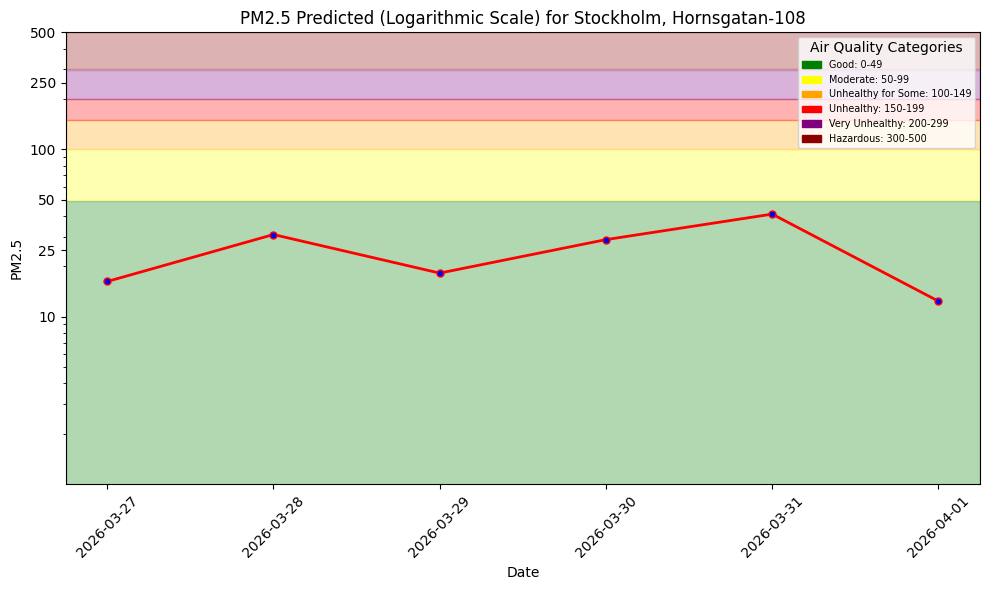

In [12]:

pred_file_path = f"{root_dir}/docs/air-quality/assets/img/pm25_forecast.png"
plt = util.plot_air_quality_forecast(city, street, batch_data, pred_file_path)

plt.show()

In [13]:
# Get or create feature group
monitor_fg = fs.get_or_create_feature_group(
    name='aq_predictions',
    description='Air Quality prediction monitoring',
    version=1,
    primary_key=['city','street','date','days_before_forecast_day'],
    event_time="date"
)

In [14]:
monitor_fg.insert(batch_data, wait=True)

2026-03-26 09:00:11,126 INFO: Computing insert statistics


(None, None)

In [15]:
# We will create a hindcast chart for  only the forecasts made 1 day beforehand
monitoring_df = monitor_fg.filter(monitor_fg.days_before_forecast_day == 1).read()
monitoring_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.52s) 


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,predicted_pm25,street,country,days_before_forecast_day
0,2026-03-26,9.6125,0.0,10.703569,250.346085,Stockholm,37.283592,Hornsgatan-108,Sweden,1
1,2026-03-27,10.6125,0.0,14.205182,261.253906,Stockholm,16.253975,Hornsgatan-108,Sweden,1


In [16]:
air_quality_fg = fs.get_feature_group(name='air_quality', version=1)
air_quality_df = air_quality_fg.read()
air_quality_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.49s) 


,date,pm25,country,city,street,url
0,2025-07-01,14.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
1,2025-07-02,27.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
2,2025-07-03,22.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
3,2025-07-04,9.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
4,2025-07-05,15.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
...,...,...,...,...,...,...
2770,2017-12-27,10.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
2771,2017-12-28,55.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
2772,2017-12-29,42.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
2773,2017-12-30,16.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009


In [17]:
outcome_df = air_quality_df[['date', 'pm25']]
preds_df =  monitoring_df[['date', 'predicted_pm25']]

hindcast_df = pd.merge(preds_df, outcome_df, on="date")
hindcast_df = hindcast_df.sort_values(by=['date'])

# If there are no outcomes for predictions yet, generate some predictions/outcomes from existing data
if len(hindcast_df) == 0:
    hindcast_df = util.backfill_predictions_for_monitoring(weather_fg, air_quality_df, monitor_fg, retrieved_xgboost_model)
hindcast_df

,date,predicted_pm25,pm25
0,2026-03-26,37.283592,7.0


### Plot the Hindcast comparing predicted with forecasted values (1-day prior forecast)

__This graph will be empty to begin with - this is normal.__

After a few days of predictions and observations, you will get data points in this graph.

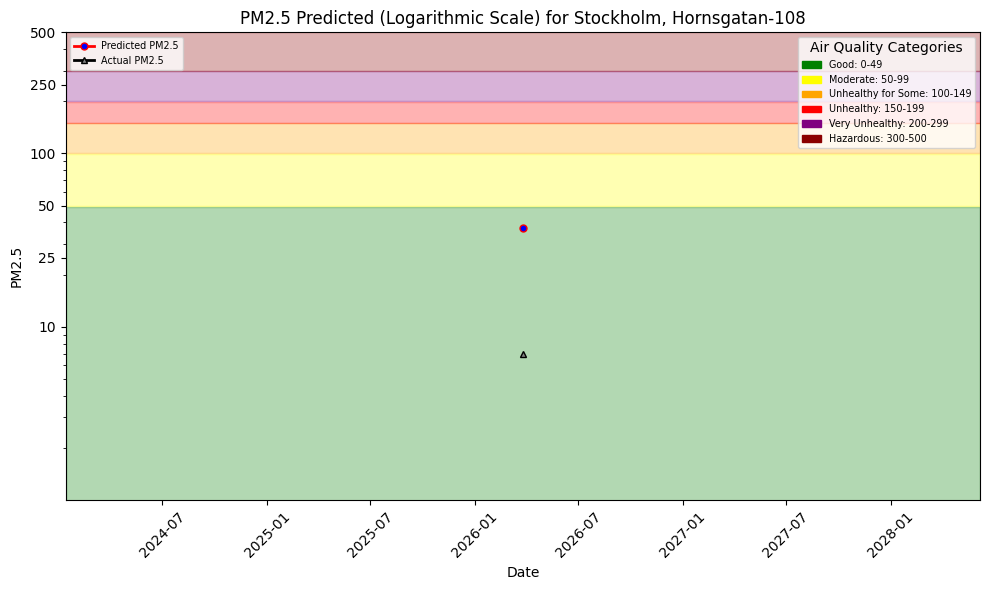

In [18]:
hindcast_file_path = f"{root_dir}/docs/air-quality/assets/img/pm25_hindcast_1day.png"
plt = util.plot_air_quality_forecast(city, street, hindcast_df, hindcast_file_path, hindcast=True)
plt.show()

### Upload the prediction and hindcast dashboards (png files) to Hopsworks


In [19]:
dataset_api = project.get_dataset_api()
str_today = today.strftime("%Y-%m-%d")
if dataset_api.exists("Resources/airquality") == False:
    dataset_api.mkdir("Resources/airquality")
dataset_api.upload(pred_file_path, f"Resources/airquality/{city}_{street}_{str_today}", overwrite=True)
dataset_api.upload(hindcast_file_path, f"Resources/airquality/{city}_{street}_{str_today}", overwrite=True)

proj_url = project.get_url()
print(f"See images in Hopsworks here: {proj_url}/settings/fb/path/Resources/airquality")

Uploading /hopsfs/Users/meb10000/mlfs-book/docs/air-quality/assets/img/pm25_forecast.png: 0.000%|          | 0…

Uploading /hopsfs/Users/meb10000/mlfs-book/docs/air-quality/assets/img/pm25_hindcast_1day.png: 0.000%|        …

See images in Hopsworks here: https://hopsworks.ai.local/p/119/settings/fb/path/Resources/airquality


### Upload training hindcast from model artifacts to Resources

In [20]:
import os

training_hindcast_path = os.path.join(saved_model_dir, "images", "pm25_hindcast.png")
if os.path.exists(training_hindcast_path):
    dataset_api.upload(training_hindcast_path, "Resources/airquality", overwrite=True)
    print(f"Uploaded training hindcast to Resources/airquality/pm25_hindcast.png")
else:
    print(f"Warning: Training hindcast not found at {training_hindcast_path}")

Uploading /tmp/80273c37-e6f0-4d13-a1ac-ecc23a99a615/air_quality_xgboost_model/1/images/pm25_hindcast.png: 0.00…

Uploaded training hindcast to Resources/airquality/pm25_hindcast.png


### Create Hopsworks Dashboard with forecast and hindcast charts

In [ ]:
import subprocess
import json as json_mod
import os

CHART_DIR = "/hopsfs/Resources/charts/airquality"
os.makedirs(CHART_DIR, exist_ok=True)

proj_url = project.get_url()
from hopsworks_common import client as hw_client
_client = hw_client.get_instance()
project_id = _client._project_id

# --- Self-contained Plotly HTML template (same pattern as duckdb_benchmarks) ---
PLOTLY_TEMPLATE = """<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<style>
  body {{ margin: 0; padding: 0; background: #fff; overflow: visible; }}
  #chart {{ width: 100vw; height: 100vh; overflow: visible; }}
  .main-svg, .main-svg .draglayer, .main-svg .layer-above {{ overflow: visible !important; }}
  svg {{ overflow: visible !important; }}
</style>
</head>
<body>
<div id="chart"></div>
<script>
var traces = {traces};
var layout = {layout};
var config = {{responsive: true, displayModeBar: false}};
Plotly.newPlot('chart', traces, layout, config);
window.addEventListener('resize', function() {{
  Plotly.Plots.resize(document.getElementById('chart'));
}});
</script>
</body>
</html>"""

AQI_BANDS = [
    (0, 49, "rgba(0,128,0,0.2)", "Good"),
    (50, 99, "rgba(255,255,0,0.2)", "Moderate"),
    (100, 149, "rgba(255,165,0,0.2)", "Unhealthy for Some"),
    (150, 199, "rgba(255,0,0,0.2)", "Unhealthy"),
    (200, 299, "rgba(128,0,128,0.2)", "Very Unhealthy"),
    (300, 500, "rgba(139,0,0,0.2)", "Hazardous"),
]
AQI_LEGEND_COLORS = ["green", "yellow", "orange", "red", "purple", "darkred"]

def make_aqi_shapes():
    return [dict(type="rect", xref="paper", x0=0, x1=1, yref="y",
                 y0=lo, y1=hi, fillcolor=c, line_width=0)
            for lo, hi, c, _ in AQI_BANDS]

def make_aqi_legend_traces():
    return [dict(type="scatter", x=[None], y=[None], mode="markers",
                 marker=dict(size=10, color=AQI_LEGEND_COLORS[i]),
                 name=f"{label}: {lo}-{hi}", showlegend=True)
            for i, (lo, hi, _, label) in enumerate(AQI_BANDS)]

def make_layout(title):
    return dict(
        title=dict(text=title, font=dict(size=18)),
        xaxis=dict(title="Date"),
        yaxis=dict(title="PM2.5", type="log",
                   tickvals=[10, 25, 50, 100, 250, 500],
                   range=[0, 2.7]),
        showlegend=True,
        legend=dict(orientation="h", x=0.5, y=-0.25, xanchor="center",
                    yanchor="top", font=dict(size=10),
                    bgcolor="rgba(255,255,255,0.9)",
                    bordercolor="#ccc", borderwidth=1),
        margin=dict(t=60, b=140, l=60, r=30),
        shapes=make_aqi_shapes(),
    )

def write_chart_html(filename, traces, title):
    path = f"{CHART_DIR}/{filename}"
    with open(path, "w") as f:
        f.write(PLOTLY_TEMPLATE.format(
            traces=json_mod.dumps(traces), layout=json_mod.dumps(make_layout(title))))
    print(f"  Wrote {filename}")

def run_hops(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"Error: {cmd}\n{result.stderr}")
    return result.stdout.strip()

def hops_json(args):
    result = subprocess.run(["hops"] + args + ["--json"], capture_output=True, text=True)
    if result.returncode != 0:
        return []
    try:
        return json_mod.loads(result.stdout)
    except json_mod.JSONDecodeError:
        return []

def parse_id(output):
    for word in output.split():
        cleaned = word.strip("()")
        if cleaned.isdigit():
            return int(cleaned)
    return None

# --- Chart 1: Forecast (uses batch_data from earlier cells) ---
forecast_dates = [str(d) for d in pd.to_datetime(batch_data['date']).dt.date]
forecast_vals = [round(float(v), 2) for v in batch_data['predicted_pm25']]
traces = [dict(type="scatter", mode="lines+markers", name="Predicted PM2.5",
               x=forecast_dates, y=forecast_vals,
               line=dict(color="red", width=2), marker=dict(size=6, color="blue"))]
traces += make_aqi_legend_traces()
write_chart_html("pm25_forecast.html", traces, f"PM2.5 Forecast — {city}, {street}")

# --- Chart 2: Inference Hindcast (uses hindcast_df from earlier cells) ---
hc_dates = [str(d) for d in pd.to_datetime(hindcast_df['date']).dt.date]
hc_pred = [round(float(v), 2) for v in hindcast_df['predicted_pm25']]
hc_actual = [round(float(v), 2) for v in hindcast_df['pm25']]
traces = [
    dict(type="scatter", mode="lines+markers", name="Predicted PM2.5",
         x=hc_dates, y=hc_pred, line=dict(color="red", width=2),
         marker=dict(size=6, color="blue")),
    dict(type="scatter", mode="lines+markers", name="Actual PM2.5",
         x=hc_dates, y=hc_actual, line=dict(color="black", width=2),
         marker=dict(size=6, color="grey", symbol="triangle-up")),
]
traces += make_aqi_legend_traces()
write_chart_html("pm25_inference_hindcast.html", traces,
                 f"PM2.5 Inference Hindcast — {city}, {street}")

# --- Chart 3: Recent Air Quality History (uses air_quality_df from earlier cells) ---
sorted_aq = air_quality_df.sort_values('date').tail(100)
aq_dates = [str(d) for d in pd.to_datetime(sorted_aq['date']).dt.date]
aq_vals = [round(float(v), 2) for v in sorted_aq['pm25']]
traces = [dict(type="scatter", mode="lines+markers", name="Actual PM2.5",
               x=aq_dates, y=aq_vals, line=dict(color="black", width=2),
               marker=dict(size=4, color="grey"))]
traces += make_aqi_legend_traces()
write_chart_html("pm25_history.html", traces, f"PM2.5 Recent History — {city}, {street}")

# --- Delete existing dashboard and charts (idempotent) ---
existing_dashboards = hops_json(["dashboard", "list"])
if existing_dashboards and isinstance(existing_dashboards, list):
    for d in existing_dashboards:
        if d.get("name") == "Air Quality Dashboard":
            run_hops(f'hops dashboard delete {d["id"]}')
            print(f"  Deleted dashboard {d['id']}")

existing_charts = hops_json(["chart", "list"])
if existing_charts and isinstance(existing_charts, list):
    for c in existing_charts:
        if "PM2.5" in c.get("title", ""):
            run_hops(f'hops chart delete {c["id"]}')
            print(f"  Deleted chart {c['id']}: {c['title']}")

# --- Create charts and dashboard ---
chart_configs = [
    ("pm25_forecast.html", f"PM2.5 Forecast - {city}",
     f"Air quality PM2.5 forecast for {city}, {street}"),
    ("pm25_inference_hindcast.html", f"PM2.5 Inference Hindcast - {city}",
     f"1-day-ahead PM2.5 predictions vs actuals for {city}, {street}"),
    ("pm25_history.html", f"PM2.5 History - {city}",
     f"Recent PM2.5 measurements for {city}, {street}"),
]

chart_ids = []
for filename, title, description in chart_configs:
    url = f"Resources/charts/airquality/{filename}"
    output = run_hops(f'hops chart create "{title}" --url "{url}" --description "{description}"')
    cid = parse_id(output)
    chart_ids.append(cid)
    print(f"  Created chart '{title}' (ID: {cid})")

output = run_hops('hops dashboard create "Air Quality Dashboard"')
dash_id = parse_id(output)
for i, cid in enumerate(chart_ids):
    run_hops(f"hops dashboard add-chart {dash_id} --chart-id {cid} --width 24 --height 10 --x 0 --y {i * 10}")

print(run_hops(f"hops dashboard info {dash_id}"))
print(f"\nView dashboard at: {proj_url}/p/{project_id}/dashboards/{dash_id}")

---